In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import RobustScaler
import math
from collections import Counter
import re
from wordcloud import WordCloud
import nltk
from nltk.corpus import stopwords
from sklearn.feature_extraction.text import CountVectorizer
from nltk.sentiment import SentimentIntensityAnalyzer
import string
import matplotlib.pyplot as plt
from collections import Counter
from nltk.tokenize import word_tokenize
from nltk.corpus import stopwords
from nltk.stem import PorterStemmer, WordNetLemmatizer
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.model_selection import train_test_split
from sklearn.naive_bayes import MultinomialNB
from sklearn.svm import LinearSVC
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix

In [2]:
# data ingestion and creating a column for the target class
fake = pd.read_csv('/Users/islamso/Downloads/News _dataset/Fake.csv')  
fake['class'] = 1  # 1 = fake news
fake.head()

,title,text,subject,date,class
0,Donald Trump Sends Out Embarrassing New Year’...,Donald Trump just couldn t wish all Americans ...,News,"December 31, 2017",1
1,Drunk Bragging Trump Staffer Started Russian ...,House Intelligence Committee Chairman Devin Nu...,News,"December 31, 2017",1
2,Sheriff David Clarke Becomes An Internet Joke...,"On Friday, it was revealed that former Milwauk...",News,"December 30, 2017",1
3,Trump Is So Obsessed He Even Has Obama’s Name...,"On Christmas day, Donald Trump announced that ...",News,"December 29, 2017",1
4,Pope Francis Just Called Out Donald Trump Dur...,Pope Francis used his annual Christmas Day mes...,News,"December 25, 2017",1


In [3]:
# data ingestion and creating a column for the target class
true = pd.read_csv('/Users/islamso/Downloads/News _dataset/True.csv')  
true['class'] = 0  # 0 = real news
true.head()

,title,text,subject,date,class
0,"As U.S. budget fight looms, Republicans flip t...",WASHINGTON (Reuters) - The head of a conservat...,politicsNews,"December 31, 2017",0
1,U.S. military to accept transgender recruits o...,WASHINGTON (Reuters) - Transgender people will...,politicsNews,"December 29, 2017",0
2,Senior U.S. Republican senator: 'Let Mr. Muell...,WASHINGTON (Reuters) - The special counsel inv...,politicsNews,"December 31, 2017",0
3,FBI Russia probe helped by Australian diplomat...,WASHINGTON (Reuters) - Trump campaign adviser ...,politicsNews,"December 30, 2017",0
4,Trump wants Postal Service to charge 'much mor...,SEATTLE/WASHINGTON (Reuters) - President Donal...,politicsNews,"December 29, 2017",0


In [4]:
# combining both datasets into one dataset
df = pd.concat([fake, true], ignore_index=True)
df.head()

,title,text,subject,date,class
0,Donald Trump Sends Out Embarrassing New Year’...,Donald Trump just couldn t wish all Americans ...,News,"December 31, 2017",1
1,Drunk Bragging Trump Staffer Started Russian ...,House Intelligence Committee Chairman Devin Nu...,News,"December 31, 2017",1
2,Sheriff David Clarke Becomes An Internet Joke...,"On Friday, it was revealed that former Milwauk...",News,"December 30, 2017",1
3,Trump Is So Obsessed He Even Has Obama’s Name...,"On Christmas day, Donald Trump announced that ...",News,"December 29, 2017",1
4,Pope Francis Just Called Out Donald Trump Dur...,Pope Francis used his annual Christmas Day mes...,News,"December 25, 2017",1


In [5]:
def light_clean(text):
    text = str(text)
    
    # Removing Reuters patterns 
    text = re.sub(r'\b[A-Z][A-Z\s]{2,}\s*\(Reuters\)', '', text)
    text = re.sub(r'\(Reuters\)', '', text)
    
    # Lowercase
    text = text.lower()
    
    # Remove URLs
    text = re.sub(r'http\S+|www\S+|https\S+', '', text)
    
    # Remove punctuation
    text = re.sub(r'[^\w\s]', '', text)
    
    # Remove extra spaces
    text = re.sub(r'\s+', ' ', text).strip()
    
    return text

# Apply to dataframe (create new cleaned column)
df['clean_title'] = df['title'].apply(light_clean)
df['clean_text'] = df['text'].apply(light_clean)
df.head()

,title,text,subject,date,class,clean_title,clean_text
0,Donald Trump Sends Out Embarrassing New Year’...,Donald Trump just couldn t wish all Americans ...,News,"December 31, 2017",1,donald trump sends out embarrassing new years ...,donald trump just couldn t wish all americans ...
1,Drunk Bragging Trump Staffer Started Russian ...,House Intelligence Committee Chairman Devin Nu...,News,"December 31, 2017",1,drunk bragging trump staffer started russian c...,house intelligence committee chairman devin nu...
2,Sheriff David Clarke Becomes An Internet Joke...,"On Friday, it was revealed that former Milwauk...",News,"December 30, 2017",1,sheriff david clarke becomes an internet joke ...,on friday it was revealed that former milwauke...
3,Trump Is So Obsessed He Even Has Obama’s Name...,"On Christmas day, Donald Trump announced that ...",News,"December 29, 2017",1,trump is so obsessed he even has obamas name c...,on christmas day donald trump announced that h...
4,Pope Francis Just Called Out Donald Trump Dur...,Pope Francis used his annual Christmas Day mes...,News,"December 25, 2017",1,pope francis just called out donald trump duri...,pope francis used his annual christmas day mes...


In [6]:
# checking for the structure of the dataset
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 44898 entries, 0 to 44897
Data columns (total 7 columns):
 #   Column       Non-Null Count  Dtype 
---  ------       --------------  ----- 
 0   title        44898 non-null  object
 1   text         44898 non-null  object
 2   subject      44898 non-null  object
 3   date         44898 non-null  object
 4   class        44898 non-null  int64 
 5   clean_title  44898 non-null  object
 6   clean_text   44898 non-null  object
dtypes: int64(1), object(6)
memory usage: 2.4+ MB


In [7]:
# check for duplicates and dropping them
print("Duplicates before:", df.duplicated().sum())
df.drop_duplicates(inplace=True)
print("Duplicates after:", df.duplicated().sum())

Duplicates before: 209
Duplicates after: 0


In [8]:
# check foir missing values
df.isnull().sum()

title          0
text           0
subject        0
date           0
class          0
clean_title    0
clean_text     0
dtype: int64

# EDA

In [9]:
# cadinality check
df.nunique()

title          38729
text           38646
subject            8
date            2397
class              2
clean_title    38716
clean_text     38565
dtype: int64

In [10]:
pd.crosstab(df['subject'], df['class'])

class,0,1
subject,,
Government News,0,1570
Middle-east,0,778
News,0,9050
US_News,0,783
left-news,0,4459
politics,0,6838
politicsNews,11220,0
worldnews,9991,0


In [14]:
df['class'].value_counts()

class
1    23478
0    21211
Name: count, dtype: int64

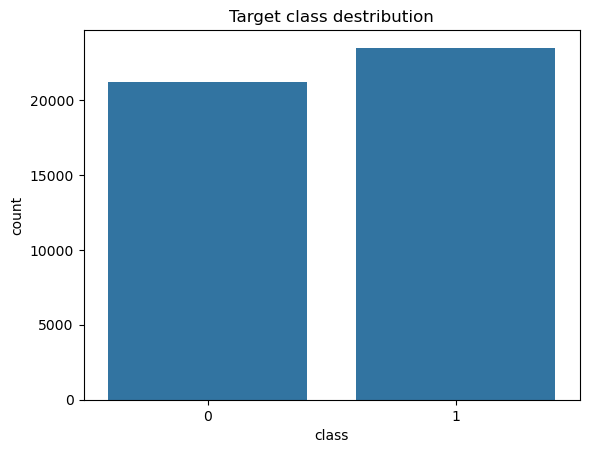

In [11]:
sns.countplot (data=df , x='class')
plt.title ('Target class destribution')
plt.show()

In [16]:
# number of words 
df['num_words'] = df['text'].apply(lambda x: len(str(x).split()))
# Number of characters
df['num_chars'] = df['text'].apply(lambda x: len(str(x)))
# Number of sentences using regex
df['num_sentences'] = df['text'].apply(lambda x: len([s for s in re.split(r'[.!?]+', str(x)) if s.strip()]))

In [17]:
# Basic stats
print(df[['num_words', 'num_chars', 'num_sentences']].describe())

          num_words     num_chars  num_sentences
count  44689.000000  44689.000000   44689.000000
mean     404.966502   2467.098682      22.234689
std      351.573770   2173.612347      19.121967
min        0.000000      1.000000       0.000000
25%      203.000000   1232.000000      11.000000
50%      362.000000   2185.000000      19.000000
75%      512.000000   3101.000000      29.000000
max     8135.000000  51794.000000     773.000000


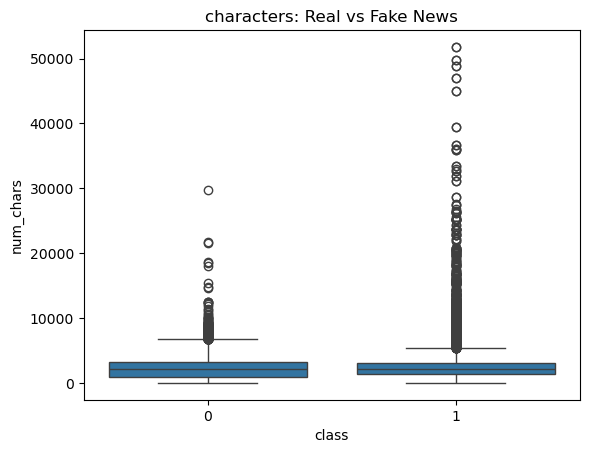

In [18]:
sns.boxplot(x='class', y='num_chars', data=df)
plt.title('characters: Real vs Fake News')
plt.show()

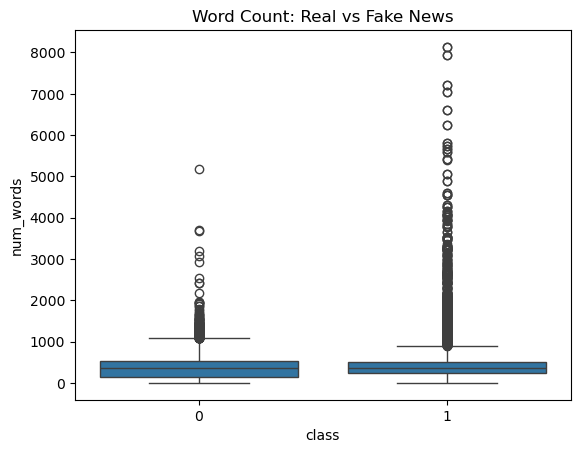

In [19]:
sns.boxplot(x='class', y='num_words', data=df)
plt.title('Word Count: Real vs Fake News')
plt.show()

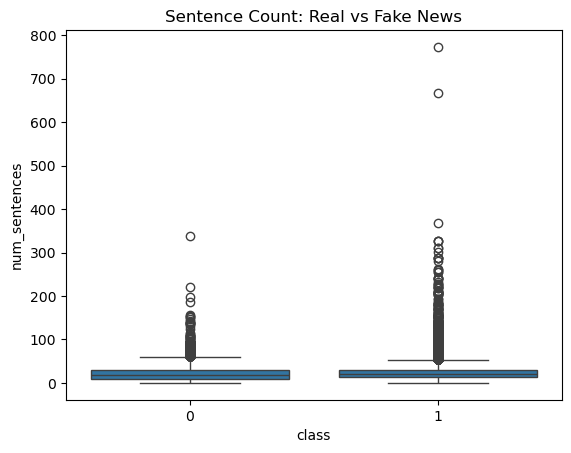

In [20]:
sns.boxplot(x='class', y='num_sentences', data=df)
plt.title('Sentence Count: Real vs Fake News')
plt.show()

[nltk_data] Downloading package stopwords to
[nltk_data]     /Users/islamso/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!


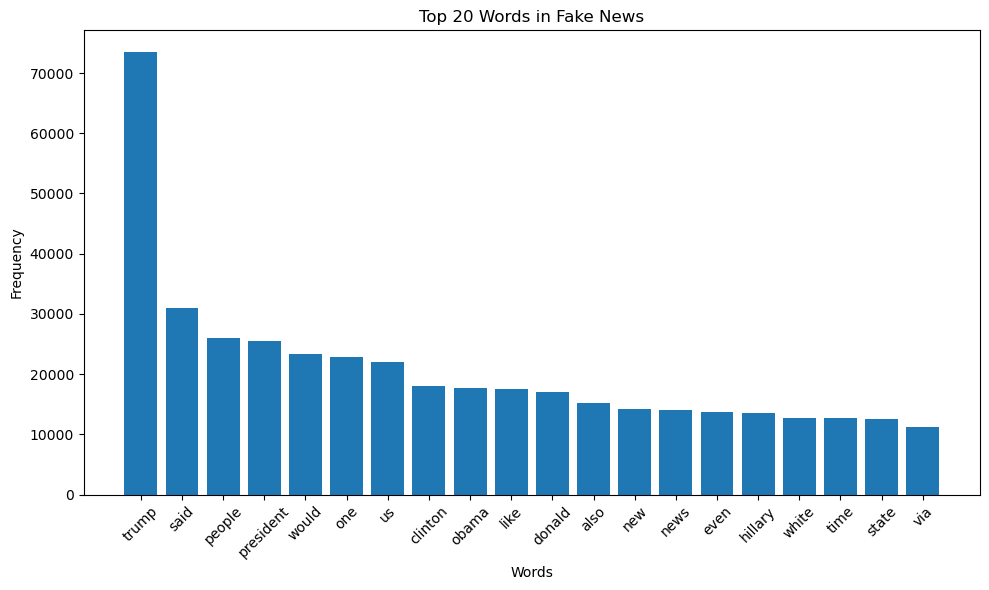

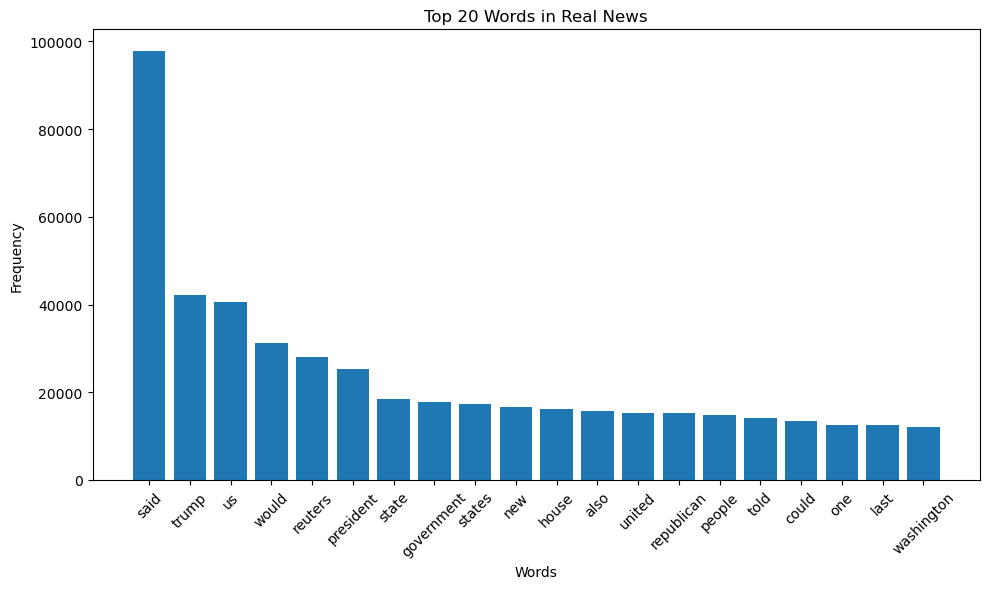

In [22]:
# Download stopwords (only first time)
nltk.download('stopwords')

# Load English stopwords
stop_words = set(stopwords.words('english'))

# Separate fake and real news text
fake_texts = df[df['class'] == 1]['text'].dropna()
real_texts = df[df['class'] == 0]['text'].dropna()

# Function to clean text and extract words
def get_words(text_series):
    words = []
    for text in text_series:
        # Remove punctuation
        text = re.sub(r'[^\w\s]', '', text)
        
        # Convert to lowercase and remove stopwords
        words += [
            word.lower() 
            for word in text.split() 
            if word.lower() not in stop_words
        ]
    return words

# Get cleaned word lists
fake_words = get_words(fake_texts)
real_words = get_words(real_texts)

# Count word frequencies
fake_counts = Counter(fake_words)
real_counts = Counter(real_words)

# Get Top 20 words
top_fake = fake_counts.most_common(20)
top_real = real_counts.most_common(20)

# Plotting function
def plot_top_words(word_counts, title):
    words, counts = zip(*word_counts)
    
    plt.figure(figsize=(10,6))
    plt.bar(words, counts)
    plt.xticks(rotation=45)
    plt.title(title)
    plt.xlabel("Words")
    plt.ylabel("Frequency")
    plt.tight_layout()
    plt.show()

# Plot Fake and Real
plot_top_words(top_fake, "Top 20 Words in Fake News")
plot_top_words(top_real, "Top 20 Words in Real News")

In [23]:
def get_top_ngrams(text_series, n=2, top_k=20):
    """
    text_series: pandas Series of text
    n: 2 for bigram, 3 for trigram
    top_k: number of top n-grams to return
    """
    vec = CountVectorizer(ngram_range=(n,n), stop_words='english')
    X = vec.fit_transform(text_series)
    counts = X.sum(axis=0).A1
    features = vec.get_feature_names_out()
    top_indices = counts.argsort()[-top_k:][::-1]  
    top_ngrams = [(features[i], counts[i]) for i in top_indices]
    return top_ngrams

In [24]:
# Bigrams
top_fake_bigrams = get_top_ngrams(fake_texts, n=2)
top_real_bigrams = get_top_ngrams(real_texts, n=2)

# Trigrams
top_fake_trigrams = get_top_ngrams(fake_texts, n=3)
top_real_trigrams = get_top_ngrams(real_texts, n=3)

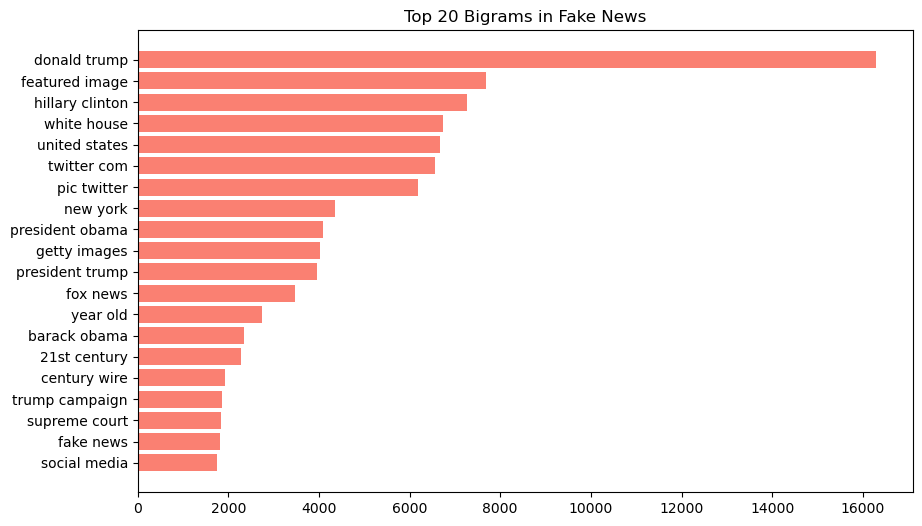

In [25]:
def plot_ngrams(top_ngrams, title):
    ngrams, counts = zip(*top_ngrams)
    plt.figure(figsize=(10,6))
    plt.barh(ngrams, counts, color='salmon')
    plt.gca().invert_yaxis()  # Largest on top
    plt.title(title)
    plt.show()


plot_ngrams(top_fake_bigrams, "Top 20 Bigrams in Fake News")


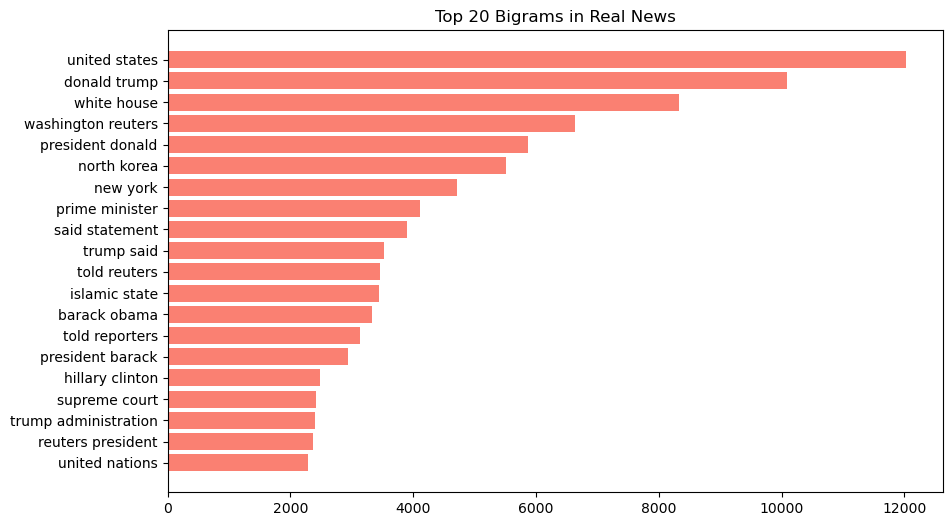

In [26]:
plot_ngrams(top_real_bigrams, "Top 20 Bigrams in Real News")

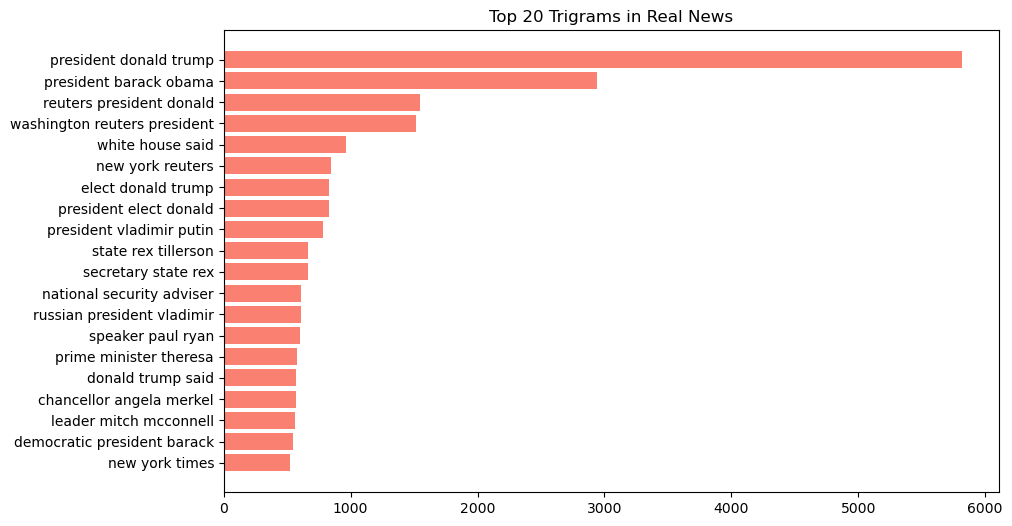

In [27]:
plot_ngrams(top_real_trigrams, "Top 20 Trigrams in Real News")

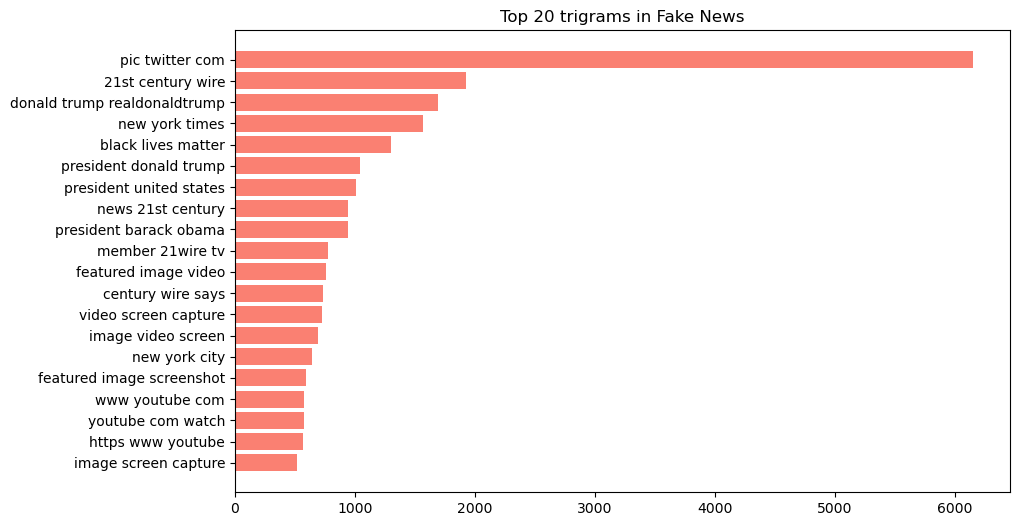

In [28]:
plot_ngrams(top_fake_trigrams, "Top 20 trigrams in Fake News")

[nltk_data] Downloading package vader_lexicon to
[nltk_data]     /Users/islamso/nltk_data...
[nltk_data]   Package vader_lexicon is already up-to-date!


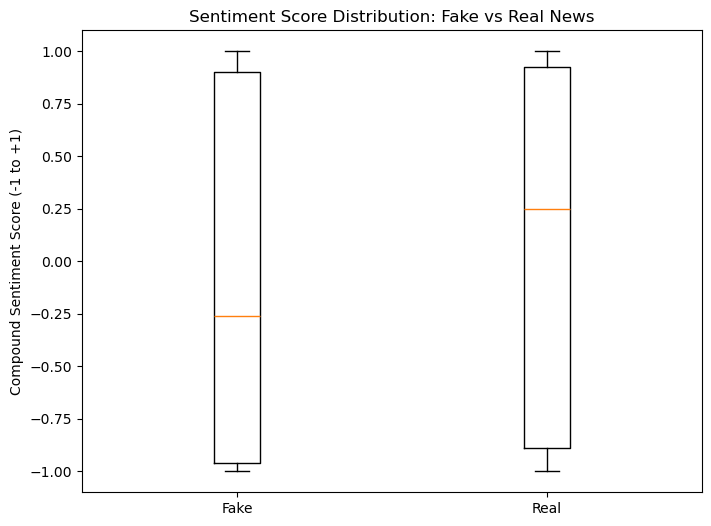

In [29]:
# Download VADER lexicon (only first time)
nltk.download('vader_lexicon')

# Initialize sentiment analyzer
sia = SentimentIntensityAnalyzer()

# Compute sentiment score for each article
df['sentiment_score'] = df['text'].apply(
    lambda x: sia.polarity_scores(str(x))['compound']
)

# Separate fake and real sentiment
fake_sentiment = df[df['class'] == 1]['sentiment_score']
real_sentiment = df[df['class'] == 0]['sentiment_score']


# BOX PLOT COMPARISON


plt.figure(figsize=(8,6))
plt.boxplot([fake_sentiment, real_sentiment], tick_labels=['Fake', 'Real'])
plt.title("Sentiment Score Distribution: Fake vs Real News")
plt.ylabel("Compound Sentiment Score (-1 to +1)")
plt.show()

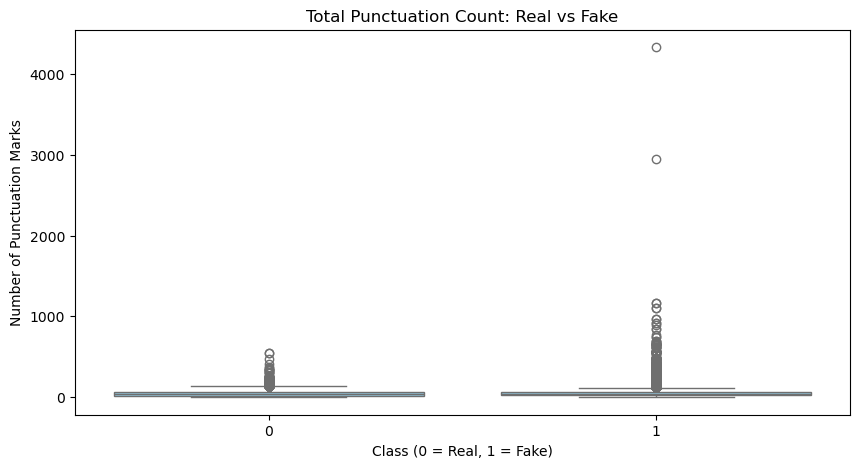

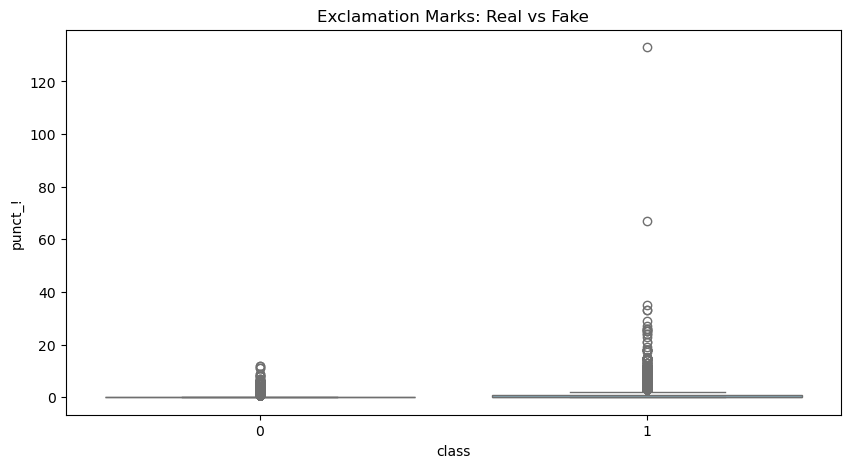

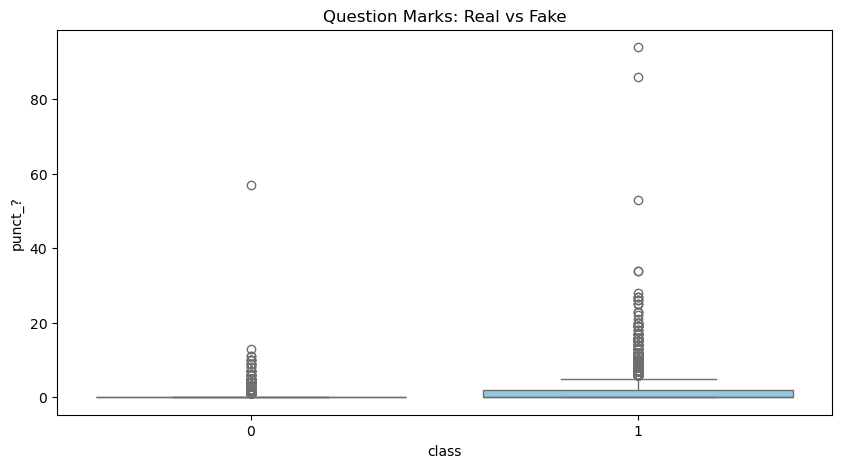

In [31]:
# Step 1 — Count specific punctuation per article
def count_punctuation(text, punct):
    return sum(1 for char in str(text) if char in punct)

# Common punctuation marks
punctuation_marks = "!?,.;:\"'()-"

# Add a new column for total punctuation
df['num_punct'] = df['text'].apply(lambda x: count_punctuation(x, punctuation_marks))

# Count each type separately
for p in punctuation_marks:
    df[f'punct_{p}'] = df['text'].apply(lambda x: count_punctuation(x, p))

# Step 2 — Visualize total punctuation


plt.figure(figsize=(10,5))
sns.boxplot(data=df, x='class', y='num_punct', color="skyblue")
plt.title("Total Punctuation Count: Real vs Fake")
plt.xlabel("Class (0 = Real, 1 = Fake)")
plt.ylabel("Number of Punctuation Marks")
plt.show()

# Step 3 — Visualize specific punctuation (! ?)
plt.figure(figsize=(10,5))
sns.boxplot(data=df, x='class', y='punct_!', color="skyblue")
plt.title("Exclamation Marks: Real vs Fake")
plt.show()

plt.figure(figsize=(10,5))
sns.boxplot(data=df, x='class', y='punct_?', color="skyblue")
plt.title("Question Marks: Real vs Fake")
plt.show()

# Data preprocessing

In [27]:
nltk.download('punkt')
nltk.download('punkt_tab')
nltk.download('stopwords')
nltk.download('wordnet')

[nltk_data] Downloading package punkt to /Users/islamso/nltk_data...
[nltk_data]   Package punkt is already up-to-date!
[nltk_data] Downloading package punkt_tab to
[nltk_data]     /Users/islamso/nltk_data...
[nltk_data]   Package punkt_tab is already up-to-date!
[nltk_data] Downloading package stopwords to
[nltk_data]     /Users/islamso/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!
[nltk_data] Downloading package wordnet to /Users/islamso/nltk_data...
[nltk_data]   Package wordnet is already up-to-date!


True

In [12]:
stop_words = set(stopwords.words('english'))
stemmer = PorterStemmer()
lemmatizer = WordNetLemmatizer()

In [13]:
def preprocess_text(text):
    # 1. Lowercasing
    text = text.lower()
    
    # 2. Tokenization
    tokens = word_tokenize(text)
    
    # 3. Remove stopwords
    tokens = [word for word in tokens if word not in stop_words]
    
    # 4. Remove non-alphabetic tokens 
    tokens = [word for word in tokens if word.isalpha()]
    
    # 5. Lemmatization 
    tokens = [lemmatizer.lemmatize(word) for word in tokens]
    
    # Join back to string
    return " ".join(tokens)

In [11]:
df['processed_text'] = df['clean_text'].apply(preprocess_text)
df['processed_title'] = df['clean_title'].apply(preprocess_text)

# Feature engineering

In [12]:
#comining title + text to give more information to the model
df['combined_text'] = df['processed_title'] + " " + df['processed_text']

In [13]:
X = df['combined_text']
y = df['class']
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

In [33]:
tfidf = TfidfVectorizer(
    max_features=5000,   # limit vocabulary size
    ngram_range=(1,2)    # unigrams + bigrams
)

In [34]:
X_train_tfidf = tfidf.fit_transform(X_train)
X_test_tfidf = tfidf.transform(X_test)

# Training and testing ML models

In [35]:
# Initialize models
models = {
    "Naive Bayes": MultinomialNB(),
    "SVM": LinearSVC(),
    "Random Forest": RandomForestClassifier(n_estimators=100, random_state=42)
}

results = []

# Train and evaluate each model
for name, model in models.items():
    model.fit(X_train_tfidf, y_train)
    y_pred = model.predict(X_test_tfidf)
    
    acc = accuracy_score(y_test, y_pred)
    precision = precision_score(y_test, y_pred)
    recall = recall_score(y_test, y_pred)
    f1 = f1_score(y_test, y_pred)
    cm = confusion_matrix(y_test, y_pred)
    
    results.append([name, acc, precision, recall, f1])
    
    print(f"\n{name} Confusion Matrix:")
    print(cm)

# Create comparison table
results_df = pd.DataFrame(results, columns=["Model", "Accuracy", "Precision", "Recall", "F1-score"])

print("\nModel Comparison:")
print(results_df)


Naive Bayes Confusion Matrix:
[[3918  282]
 [ 264 4474]]

SVM Confusion Matrix:
[[4155   45]
 [  32 4706]]

Random Forest Confusion Matrix:
[[4157   43]
 [  58 4680]]

Model Comparison:
           Model  Accuracy  Precision    Recall  F1-score
0    Naive Bayes  0.938913   0.940706  0.944280  0.942490
1            SVM  0.991385   0.990528  0.993246  0.991885
2  Random Forest  0.988700   0.990896  0.987759  0.989325
